# Modeling

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

df = pd.read_csv("../data/cleaned_base.csv")
print(f"Full dataset shape: {df.shape}")
print(f"Fraud rate: {df['fraud_bool'].mean():.4%}")

Full dataset shape: (1000000, 53)
Fraud rate: 1.1029%


##  Stratified Sample

In [2]:
SAMPLE_SIZE = 200_000

df_sample, _ = train_test_split(
    df,
    train_size=SAMPLE_SIZE,
    stratify=df['fraud_bool'],
    random_state=42
)

print(f"Sampled shape: {df_sample.shape}")
print(f"Sampled fraud rate: {df_sample['fraud_bool'].mean():.4%} (should closely match full dataset's 1.1029%)")

Sampled shape: (200000, 53)
Sampled fraud rate: 1.1030% (should closely match full dataset's 1.1029%)


## Feature / Target Split

In [3]:
X = df_sample.drop(columns=['fraud_bool'])
y = df_sample['fraud_bool']

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

X shape: (200000, 52)
y shape: (200000,)


##  Stratified Train/Test Split

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print(f"Train shape: {X_train.shape}, fraud rate: {y_train.mean():.4%}")
print(f"Test shape:  {X_test.shape}, fraud rate: {y_test.mean():.4%}")
assert abs(y_train.mean() - y_test.mean()) < 0.001, "Train/test fraud ratios don't match — stratification failed!"
print("Stratification verified — train and test fraud ratios match.")

Train shape: (160000, 52), fraud rate: 1.1031%
Test shape:  (40000, 52), fraud rate: 1.1025%
Stratification verified — train and test fraud ratios match.


## Scale Features

In [5]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling complete.")
print(f"X_train_scaled shape: {X_train_scaled.shape}")
print(f"X_test_scaled shape: {X_test_scaled.shape}")

Scaling complete.
X_train_scaled shape: (160000, 52)
X_test_scaled shape: (40000, 52)


# Train Baseline Logistic Regression

In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

model = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
model.fit(X_train_scaled, y_train)

print("Model trained.")

Model trained.


## Evaluate on Test Set

In [7]:
y_pred = model.predict(X_test_scaled)

print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Not Fraud', 'Fraud']))

Classification Report:
              precision    recall  f1-score   support

   Not Fraud       1.00      0.81      0.89     39559
       Fraud       0.05      0.82      0.09       441

    accuracy                           0.81     40000
   macro avg       0.52      0.81      0.49     40000
weighted avg       0.99      0.81      0.88     40000



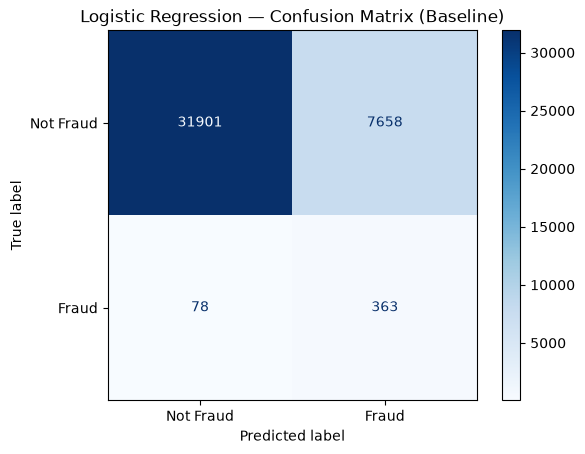


Confusion matrix breakdown:
True Negatives (correctly identified as not fraud):  31901
False Positives (wrongly flagged as fraud):          7658
False Negatives (missed fraud):                      78
True Positives (correctly caught fraud):             363


In [8]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Fraud', 'Fraud'])
disp.plot(cmap='Blues', values_format='d')
plt.title('Logistic Regression — Confusion Matrix (Baseline)')
plt.savefig('../screenshots/day4_confusion_matrix.png', dpi=100, bbox_inches='tight')
plt.show()

print("\nConfusion matrix breakdown:")
print(f"True Negatives (correctly identified as not fraud):  {cm[0][0]}")
print(f"False Positives (wrongly flagged as fraud):          {cm[0][1]}")
print(f"False Negatives (missed fraud):                      {cm[1][0]}")
print(f"True Positives (correctly caught fraud):             {cm[1][1]}")

In [9]:
from sklearn.metrics import precision_score, recall_score, f1_score
import json

baseline_metrics = {
    "model": "Logistic Regression (class_weight=balanced)",
    "sample_size": SAMPLE_SIZE,
    "train_size": len(X_train),
    "test_size": len(X_test),
    "precision_fraud": round(precision_score(y_test, y_pred), 4),
    "recall_fraud": round(recall_score(y_test, y_pred), 4),
    "f1_fraud": round(f1_score(y_test, y_pred), 4),
    "true_positives": int(cm[1][1]),
    "false_positives": int(cm[0][1]),
    "false_negatives": int(cm[1][0]),
    "true_negatives": int(cm[0][0]),
}

print(json.dumps(baseline_metrics, indent=2))

with open('../model_baseline_metrics.json', 'w') as f:
    json.dump(baseline_metrics, f, indent=2)

print("\nSaved to model_baseline_metrics.json")

{
  "model": "Logistic Regression (class_weight=balanced)",
  "sample_size": 200000,
  "train_size": 160000,
  "test_size": 40000,
  "precision_fraud": 0.0453,
  "recall_fraud": 0.8231,
  "f1_fraud": 0.0858,
  "true_positives": 363,
  "false_positives": 7658,
  "false_negatives": 78,
  "true_negatives": 31901
}

Saved to model_baseline_metrics.json
